# Split Inference — Kết quả đo đạc
Vẽ biểu đồ từ dữ liệu 9 edge + 3 cloud, 3 mode: Only Edge / Hungarian Split / Only Cloud

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

%matplotlib inline
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'white'
plt.style.use('default')

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'axes.facecolor': 'white',
    'figure.facecolor': 'white',
    'savefig.facecolor': 'white',
    'axes.facecolor': 'white',
    'figure.facecolor': 'white',
    'savefig.facecolor': 'white',
    'axes.edgecolor': '#333333',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

os.makedirs('charts', exist_ok=True)
print('Setup done.')

Setup done.


In [60]:
# ── Dữ liệu summary từ terminal ──────────────────────────────────────────────
hung_clusters = {
    'Cluster 1\n(device_1, cut=14\n6 edges)': {
        'edge_lat': 7934.623, 'edge_fps': 3.985, 'edge_ram': 1112.098,
        'msg_mb': 21.209, 'cloud_lat': 1856.535, 'cloud_fps': 15.734,
        'cloud_ram': 1298.134, 'e2e': 65729.996,
    },
    'Cluster 2\n(device_4, cut=12\n2 edges)': {
        'edge_lat': 5393.21, 'edge_fps': 5.457, 'edge_ram': 1090.372,
        'msg_mb': 23.229, 'cloud_lat': 3232.631, 'cloud_fps': 9.305,
        'cloud_ram': 1189.555, 'e2e': 30035.831,
    },
    'Cluster 3\n(device_7, cut=20\n1 edge)': {
        'edge_lat': 3549.649, 'edge_fps': 8.72, 'edge_ram': 1386.083,
        'msg_mb': 31.816, 'cloud_lat': 4399.866, 'cloud_fps': 6.786,
        'cloud_ram': 949.779, 'e2e': 24302.057,
    },
}

only_edge_machines = {
    'device_2':  {'lat': 3174.64,  'fps': 9.747, 'ram': 1505.972},
    'machine_9': {'lat': 9074.799, 'fps': 3.309, 'ram': 1396.317},
    'machine_8': {'lat': 9714.457, 'fps': 3.104, 'ram': 1387.78},
    'machine_7': {'lat': 12219.304,'fps': 2.625, 'ram': 1397.864},
    'machine_6': {'lat': 14281.538,'fps': 2.330, 'ram': 1323.381},
    'machine_5': {'lat': 14327.51, 'fps': 2.329, 'ram': 1395.448},
    'machine_4': {'lat': 14188.782,'fps': 2.309, 'ram': 1320.119},
    'machine_3': {'lat': 13968.123,'fps': 2.355, 'ram': 1375.445},
    'machine_2': {'lat': 13783.059,'fps': 2.335, 'ram': 1242.615},
}

only_cloud_nodes = {
    'device_1': {'edge_lat': 23685.358, 'edge_fps': 2.524, 'edge_ram': 1144.345,
                 'msg_mb': 150.009, 'cloud_lat': 3292.784, 'cloud_fps': 5.714,
                 'cloud_ram': 1940.931, 'e2e': 38147.65},
    'device_4': {'edge_lat': 24928.766, 'edge_fps': 2.588, 'edge_ram': 1178.711,
                 'msg_mb': 150.009, 'cloud_lat': 5701.122, 'cloud_fps': 3.812,
                 'cloud_ram': 1685.073, 'e2e': 41593.537},
    'device_7': {'edge_lat': 25851.03,  'edge_fps': 1.918, 'edge_ram': 1142.798,
                 'msg_mb': 150.009, 'cloud_lat': 10129.351, 'cloud_fps': 2.414,
                 'cloud_ram': 1670.992, 'e2e': 45900.436},
}

TOTAL_FPS = {'Only Edge': 30.443, 'Hungarian\n(Split)': 31.825, 'Only Cloud': 11.940}
COLORS    = ['#2196F3', '#4CAF50', '#FF9800']
print('Data loaded.')

Data loaded.


## Biểu đồ 1 — System Total FPS
**Ý nghĩa:** Tổng throughput của toàn hệ thống (tổng FPS của tất cả cloud devices).

Kết quả: Hungarian ≈ Only Edge >> Only Cloud do Only Cloud bị bottleneck truyền 150MB/batch không nén.

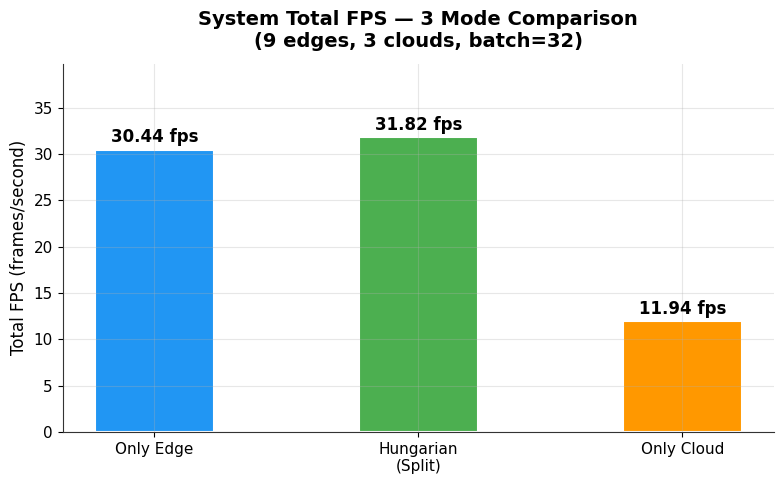

In [61]:
fig, ax = plt.subplots(figsize=(8, 5))
modes  = list(TOTAL_FPS.keys())
values = list(TOTAL_FPS.values())
bars = ax.bar(modes, values, color=COLORS, width=0.45, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{val:.2f} fps', ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_title('System Total FPS — 3 Mode Comparison\n(9 edges, 3 clouds, batch=32)', fontweight='bold', pad=12)
ax.set_ylabel('Total FPS (frames/second)')
ax.set_ylim(0, max(values) * 1.25)
plt.tight_layout()
plt.savefig('charts/chart1_total_fps.png', dpi=200, bbox_inches='tight')
plt.show()

## Chart A — FPS Breakdown (Edge FPS vs Cloud FPS)

**Ý nghĩa:** Tương tự Chart 3 (latency breakdown) nhưng cho FPS — nhất quán khi so sánh 2 chiều.

- **Edge FPS**: tốc độ edge xử lý/gửi 1 batch
- **Cloud FPS**: tốc độ cloud nhận và cho ra kết quả (= throughput đầu ra thực sự)
- Only Edge không có cloud → chỉ có edge FPS

**Kết quả:** Hungarian cloud FPS cao nhất (15.7 fps/cluster) do 6 edge liên tục đẩy dữ liệu; Only Cloud cloud FPS thấp vì phải xử lý full model từ raw frame 150MB.

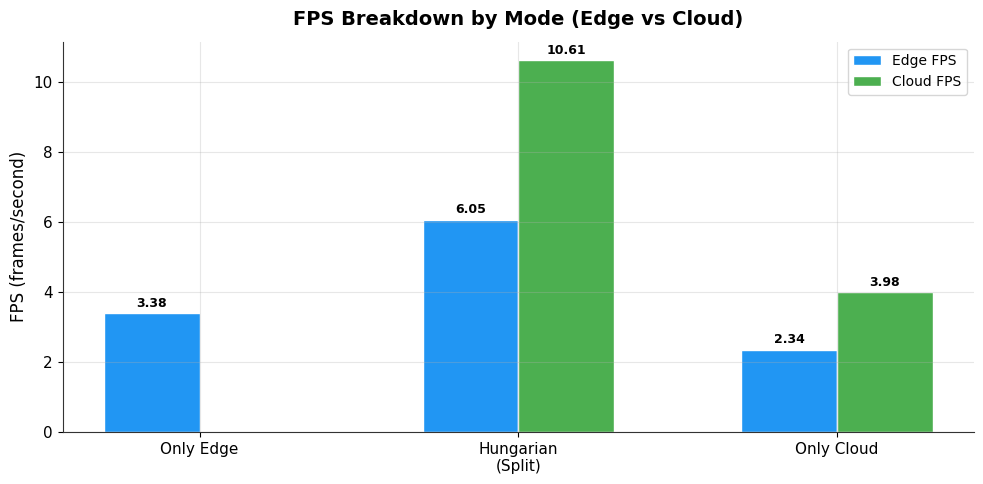

In [62]:
hu_e_fps = np.mean([v['edge_fps']  for v in hung_clusters.values()])
hu_c_fps = np.mean([v['cloud_fps'] for v in hung_clusters.values()])
oe_fps   = np.mean([v['fps']       for v in only_edge_machines.values()])
oc_e_fps = np.mean([v['edge_fps']  for v in only_cloud_nodes.values()])
oc_c_fps = np.mean([v['cloud_fps'] for v in only_cloud_nodes.values()])

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
modes = ['Only Edge', 'Hungarian\n(Split)', 'Only Cloud']
e_fps = [oe_fps,   hu_e_fps, oc_e_fps]
c_fps = [0,        hu_c_fps, oc_c_fps]

x = np.arange(len(modes))
w = 0.3
b1 = ax.bar(x - w/2, e_fps, w, label='Edge FPS',  color='#2196F3', edgecolor='white')
b2 = ax.bar(x + w/2, c_fps, w, label='Cloud FPS', color='#4CAF50', edgecolor='white')

for bar in list(b1) + list(b2):
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.1,
                f'{h:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('FPS Breakdown by Mode (Edge vs Cloud)', fontweight='bold', pad=12)
ax.set_ylabel('FPS (frames/second)')
ax.set_xticks(x)
ax.set_xticklabels(modes)
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('charts/chartA_fps_breakdown.png', dpi=200, bbox_inches='tight')
plt.show()

## Chart B — System Total FPS vs E2E Latency (Dual-Axis)

**Ý nghĩa:** So sánh throughput (FPS) và độ trễ đầu-cuối (E2E) trên cùng 1 biểu đồ.

- **Cột màu (trục trái)**: System Total FPS
- **Đường đỏ (trục phải)**: Avg E2E Latency (giây)

**Kết quả quan trọng:** Hungarian có FPS cao nhất nhưng E2E cũng cao nhất — do queue backlog ở cluster 1 (6 edge → 1 cloud). Only Edge có FPS gần bằng Hungarian nhưng E2E thấp hơn nhiều vì không có network transfer. Điều này chứng minh Hungarian tối ưu throughput tổng thể nhưng cần cân bằng cluster tốt hơn để giảm E2E.

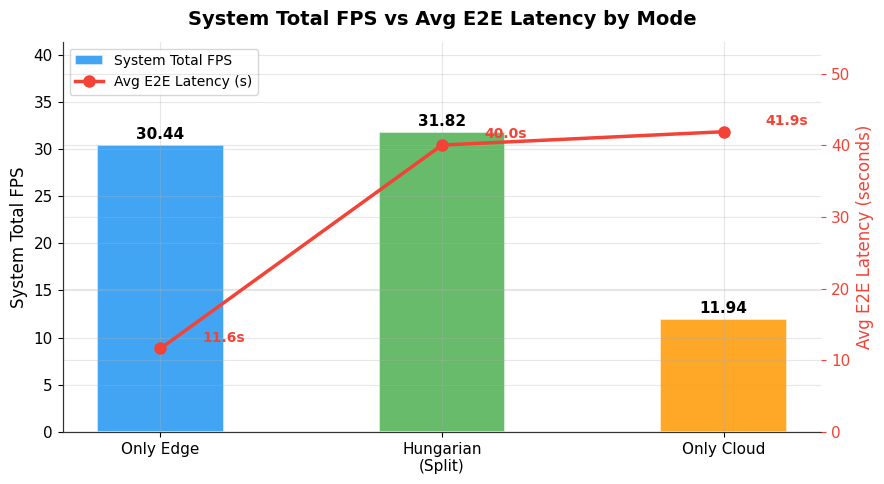

In [63]:
hu_e2e = np.mean([v['e2e'] for v in hung_clusters.values()])
oe_e2e = np.mean([v['lat'] for v in only_edge_machines.values()])
oc_e2e = np.mean([v['e2e'] for v in only_cloud_nodes.values()])

modes     = ['Only Edge', 'Hungarian\n(Split)', 'Only Cloud']
total_fps = [30.443, 31.825, 11.940]
e2e_lats  = [oe_e2e, hu_e2e, oc_e2e]
colors_fps = ['#2196F3', '#4CAF50', '#FF9800']

fig, ax1 = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('white')
ax1.set_facecolor('white')
ax2 = ax1.twinx()
ax2.set_facecolor('white')

x = np.arange(len(modes))
bars = ax1.bar(x, total_fps, 0.45, color=colors_fps, alpha=0.85,
               edgecolor='white', linewidth=1.2, label='System Total FPS')
ax2.plot(x, [l/1000 for l in e2e_lats], 'o-',
         color='#F44336', lw=2.5, ms=8, label='Avg E2E Latency (s)')

for bar, val in zip(bars, total_fps):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
for xi, val in zip(x, e2e_lats):
    ax2.text(xi + 0.15, val/1000 + 0.5, f'{val/1000:.1f}s',
             ha='left', va='bottom', color='#F44336', fontsize=10, fontweight='bold')

ax1.set_ylabel('System Total FPS', fontsize=12)
ax2.set_ylabel('Avg E2E Latency (seconds)', color='#F44336', fontsize=12)
ax2.tick_params(axis='y', colors='#F44336')
ax1.set_xticks(x)
ax1.set_xticklabels(modes)
ax1.set_ylim(0, max(total_fps) * 1.3)
ax2.set_ylim(0, max(e2e_lats)/1000 * 1.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)
ax1.set_title('System Total FPS vs Avg E2E Latency by Mode', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('charts/chartB_fps_vs_e2e.png', dpi=200, bbox_inches='tight')
plt.show()

## Chart C — FPS per Output Device

**Ý nghĩa:** Throughput trên mỗi thiết bị thực sự thực hiện inference.

- **Only Edge**: chia cho 9 edge (mỗi edge chạy full model)
- **Hungarian**: chia cho 3 cloud (cloud là nơi cho ra kết quả cuối)
- **Only Cloud**: chia cho 3 cloud (cloud chạy full model)

**Kết quả:** Hungarian đạt 10.61 fps/cloud — gấp ~2.7x Only Cloud (3.98) và ~3.1x Only Edge (3.38). Chứng minh Hungarian khai thác hiệu quả hơn mỗi thiết bị cloud nhờ pipeline split inference.

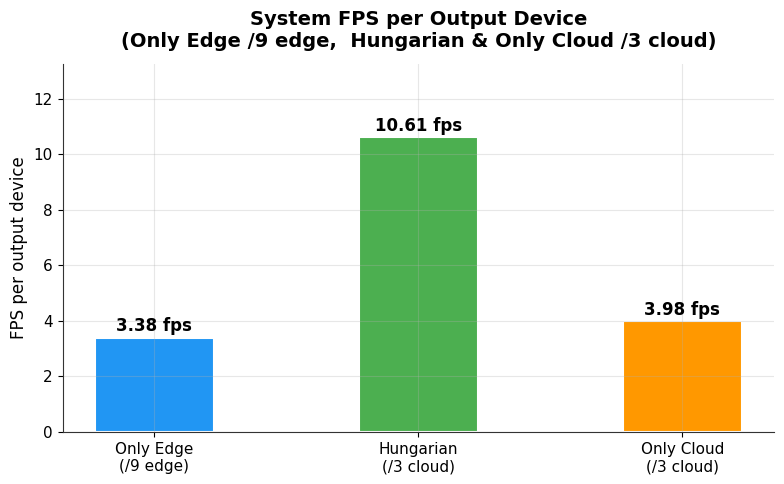

In [64]:
# Chart C: FPS per output device
fps_per_dev = [30.443/9, 31.825/3, 11.940/3]
labels      = ['Only Edge\n(/9 edge)', 'Hungarian\n(/3 cloud)', 'Only Cloud\n(/3 cloud)']
colors      = ['#2196F3', '#4CAF50', '#FF9800']

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

bars = ax.bar(labels, fps_per_dev, color=colors, width=0.45,
              edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, fps_per_dev):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.2f} fps', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_title('System FPS per Output Device\n'
             '(Only Edge /9 edge,  Hungarian & Only Cloud /3 cloud)',
             fontweight='bold', pad=12)
ax.set_ylabel('FPS per output device')
ax.set_ylim(0, max(fps_per_dev) * 1.25)
plt.tight_layout()
plt.savefig('charts/chartC_fps_per_device.png', dpi=200, bbox_inches='tight')
plt.show()

## Biểu đồ 2 — Average RAM (Stacked Bar)
**Ý nghĩa:** RAM trung bình của edge (màu đậm) và cloud (màu nhạt) cho từng mode.

- **Only Edge:** chỉ có edge RAM
- **Hungarian Split:** edge + cloud (cột chia đôi thành 2 màu)
- **Only Cloud:** edge (sender) + cloud RAM — cloud cao nhất vì chạy toàn bộ model không nén

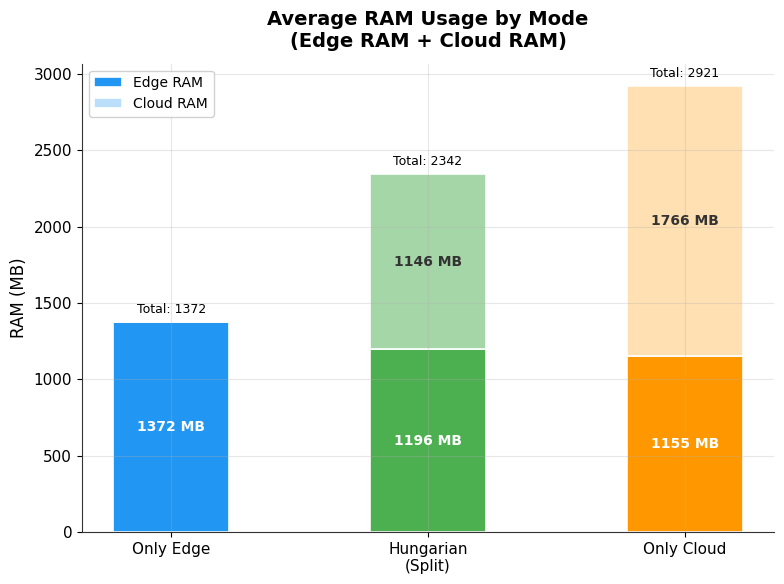

In [65]:
oe_e_ram = np.mean([v['ram']       for v in only_edge_machines.values()])
hu_e_ram = np.mean([v['edge_ram']  for v in hung_clusters.values()])
hu_c_ram = np.mean([v['cloud_ram'] for v in hung_clusters.values()])
oc_e_ram = np.mean([v['edge_ram']  for v in only_cloud_nodes.values()])
oc_c_ram = np.mean([v['cloud_ram'] for v in only_cloud_nodes.values()])

fig, ax = plt.subplots(figsize=(8, 6))
modes_r  = ['Only Edge', 'Hungarian\n(Split)', 'Only Cloud']
e_rams   = [oe_e_ram, hu_e_ram, oc_e_ram]
c_rams   = [0,        hu_c_ram, oc_c_ram]
c_edge   = ['#2196F3', '#4CAF50', '#FF9800']
c_cloud  = ['#BBDEFB', '#A5D6A7', '#FFE0B2']

ax.bar(modes_r, e_rams, color=c_edge,  width=0.45, label='Edge RAM',  edgecolor='white', linewidth=1.2)
ax.bar(modes_r, c_rams, bottom=e_rams, color=c_cloud, width=0.45, label='Cloud RAM', edgecolor='white', linewidth=1.2)

for i, (er, cr) in enumerate(zip(e_rams, c_rams)):
    ax.text(i, er/2, f'{er:.0f} MB', ha='center', va='center', fontweight='bold', color='white', fontsize=10)
    if cr > 0:
        ax.text(i, er + cr/2, f'{cr:.0f} MB', ha='center', va='center', fontweight='bold', color='#333', fontsize=10)
    ax.text(i, er + cr + 40, f'Total: {er+cr:.0f}', ha='center', va='bottom', fontsize=9)

ax.set_title('Average RAM Usage by Mode\n(Edge RAM + Cloud RAM)', fontweight='bold', pad=12)
ax.set_ylabel('RAM (MB)')
ax.legend(loc='upper left', labels=['Edge RAM', 'Cloud RAM'], framealpha=0.9)
plt.tight_layout()
plt.savefig('charts/chart2_ram_stacked.png', dpi=200, bbox_inches='tight')
plt.show()

## Biểu đồ 3 — Latency Breakdown
**Ý nghĩa:** Thời gian xử lý trung bình của edge, cloud và E2E theo mode.

- **Edge latency:** thời gian edge xử lý 1 batch
- **Cloud latency:** thời gian cloud xử lý 1 batch
- **E2E latency:** tổng từ lúc edge nhận frame → cloud ra kết quả

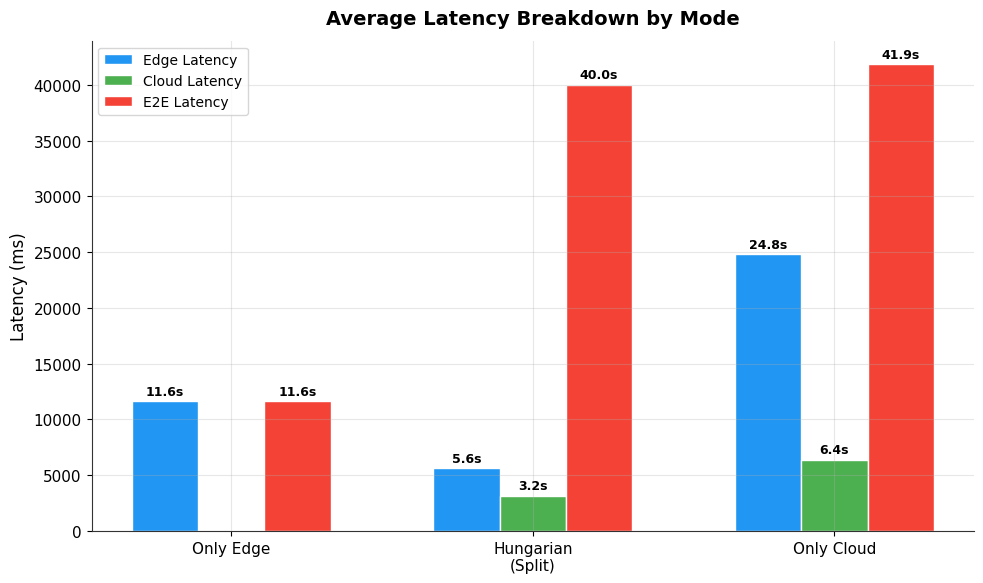

In [66]:
hu_e_lat = np.mean([v['edge_lat']  for v in hung_clusters.values()])
hu_c_lat = np.mean([v['cloud_lat'] for v in hung_clusters.values()])
hu_e2e   = np.mean([v['e2e']       for v in hung_clusters.values()])
oe_e_lat = np.mean([v['lat']       for v in only_edge_machines.values()])
oc_e_lat = np.mean([v['edge_lat']  for v in only_cloud_nodes.values()])
oc_c_lat = np.mean([v['cloud_lat'] for v in only_cloud_nodes.values()])
oc_e2e   = np.mean([v['e2e']       for v in only_cloud_nodes.values()])

fig, ax = plt.subplots(figsize=(10, 6))
modes_l  = ['Only Edge', 'Hungarian\n(Split)', 'Only Cloud']
e_lats   = [oe_e_lat, hu_e_lat, oc_e_lat]
c_lats   = [0,        hu_c_lat, oc_c_lat]
e2e_lats = [oe_e_lat, hu_e2e,   oc_e2e]

x = np.arange(len(modes_l))
w = 0.22
b1 = ax.bar(x-w, e_lats,   w, label='Edge Latency',  color='#2196F3', edgecolor='white')
b2 = ax.bar(x,   c_lats,   w, label='Cloud Latency', color='#4CAF50', edgecolor='white')
b3 = ax.bar(x+w, e2e_lats, w, label='E2E Latency',   color='#F44336', edgecolor='white')

for bars_g in [b1, b2, b3]:
    for bar in bars_g:
        h = bar.get_height()
        if h > 100:
            ax.text(bar.get_x() + bar.get_width()/2, h + 300,
                    f'{h/1000:.1f}s', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Average Latency Breakdown by Mode', fontweight='bold', pad=12)
ax.set_ylabel('Latency (ms)')
ax.set_xticks(x)
ax.set_xticklabels(modes_l)
ax.legend()
plt.tight_layout()
plt.savefig('charts/chart3_latency.png', dpi=200, bbox_inches='tight')
plt.show()

## Biểu đồ 3b — Edge & Cloud Latency (không E2E)

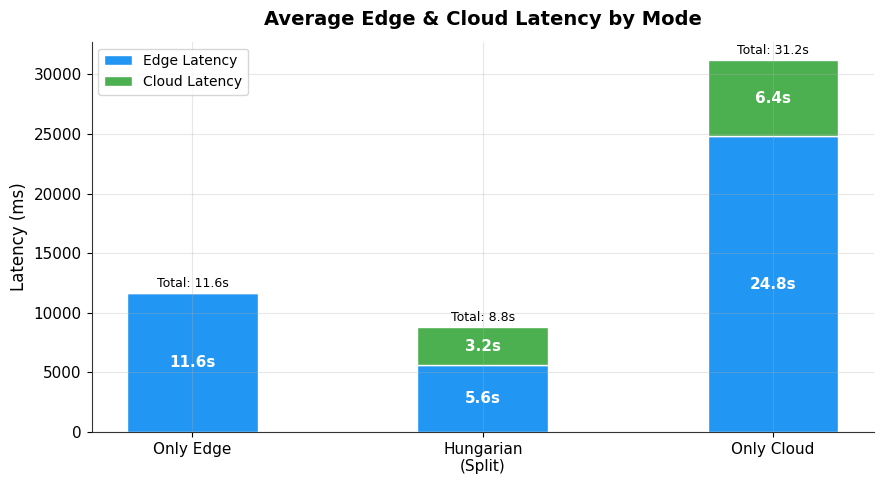

In [67]:
hu_e_lat = np.mean([v['edge_lat']  for v in hung_clusters.values()])
hu_c_lat = np.mean([v['cloud_lat'] for v in hung_clusters.values()])
oe_e_lat = np.mean([v['lat']       for v in only_edge_machines.values()])
oc_e_lat = np.mean([v['edge_lat']  for v in only_cloud_nodes.values()])
oc_c_lat = np.mean([v['cloud_lat'] for v in only_cloud_nodes.values()])

fig, ax = plt.subplots(figsize=(9, 5))
modes_l  = ['Only Edge', 'Hungarian\n(Split)', 'Only Cloud']
e_lats   = [oe_e_lat, hu_e_lat, oc_e_lat]
c_lats   = [0,        hu_c_lat, oc_c_lat]

ax.bar(modes_l, e_lats, width=0.45, label='Edge Latency',  color='#2196F3', edgecolor='white')
ax.bar(modes_l, c_lats, width=0.45, label='Cloud Latency', color='#4CAF50', edgecolor='white', bottom=e_lats)

for i, (el, cl) in enumerate(zip(e_lats, c_lats)):
    ax.text(i, el/2, f'{el/1000:.1f}s', ha='center', va='center',
            fontweight='bold', color='white', fontsize=11)
    if cl > 0:
        ax.text(i, el + cl/2, f'{cl/1000:.1f}s', ha='center', va='center',
                fontweight='bold', color='white', fontsize=11)
    ax.text(i, el + cl + 300, f'Total: {(el+cl)/1000:.1f}s',
            ha='center', va='bottom', fontsize=9)

ax.set_title('Average Edge & Cloud Latency by Mode', fontweight='bold', pad=12)
ax.set_ylabel('Latency (ms)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('charts/chart3b_latency_stacked.png', dpi=200, bbox_inches='tight')
plt.show()

## Biểu đồ 4 — Message Size
**Ý nghĩa:** Kích thước dữ liệu mỗi batch truyền từ edge lên cloud.

Q-DeltaMask 8-bit nén được ~5–7x so với raw frame (150MB).

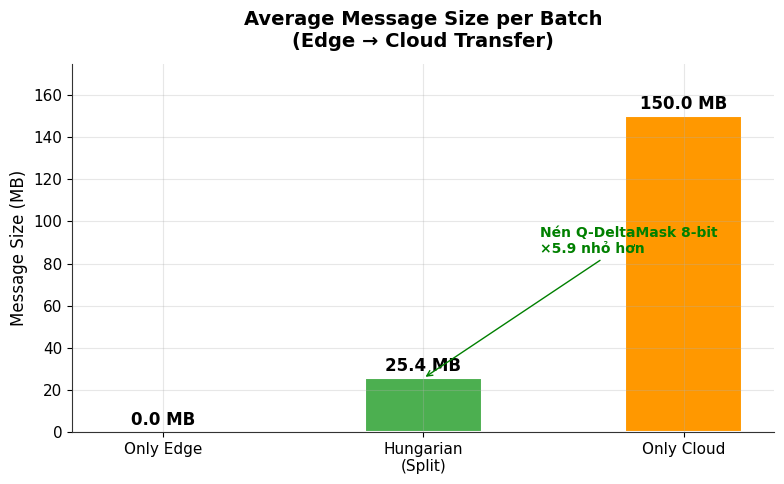

In [68]:
hu_msg = np.mean([v['msg_mb'] for v in hung_clusters.values()])

fig, ax = plt.subplots(figsize=(8, 5))
modes_m  = ['Only Edge', 'Hungarian\n(Split)', 'Only Cloud']
msg_vals = [0, hu_msg, 150.009]
bars = ax.bar(modes_m, msg_vals, color=COLORS, width=0.45, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, msg_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{val:.1f} MB', ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_title('Average Message Size per Batch\n(Edge → Cloud Transfer)', fontweight='bold', pad=12)
ax.set_ylabel('Message Size (MB)')
ax.set_ylim(0, 175)
reduction = 150.009 / hu_msg
ax.annotate(f'Nén Q-DeltaMask 8-bit\n×{reduction:.1f} nhỏ hơn',
            xy=(1, hu_msg), xytext=(1.45, 85),
            arrowprops=dict(arrowstyle='->', color='green'),
            color='green', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig('charts/chart4_msg_size.png', dpi=200, bbox_inches='tight')
plt.show()

## Biểu đồ 5 — Per-Batch FPS Trend (Hungarian)
**Ý nghĩa:** FPS của edge và cloud theo từng batch trong mỗi cluster.

- Cluster 1 (6 edges): cloud FPS cao nhất vì nhiều edge liên tục đẩy dữ liệu
- Cluster 3 (1 edge, cut=19): edge nhanh nhất vì cut sâu → edge ít layer hơn

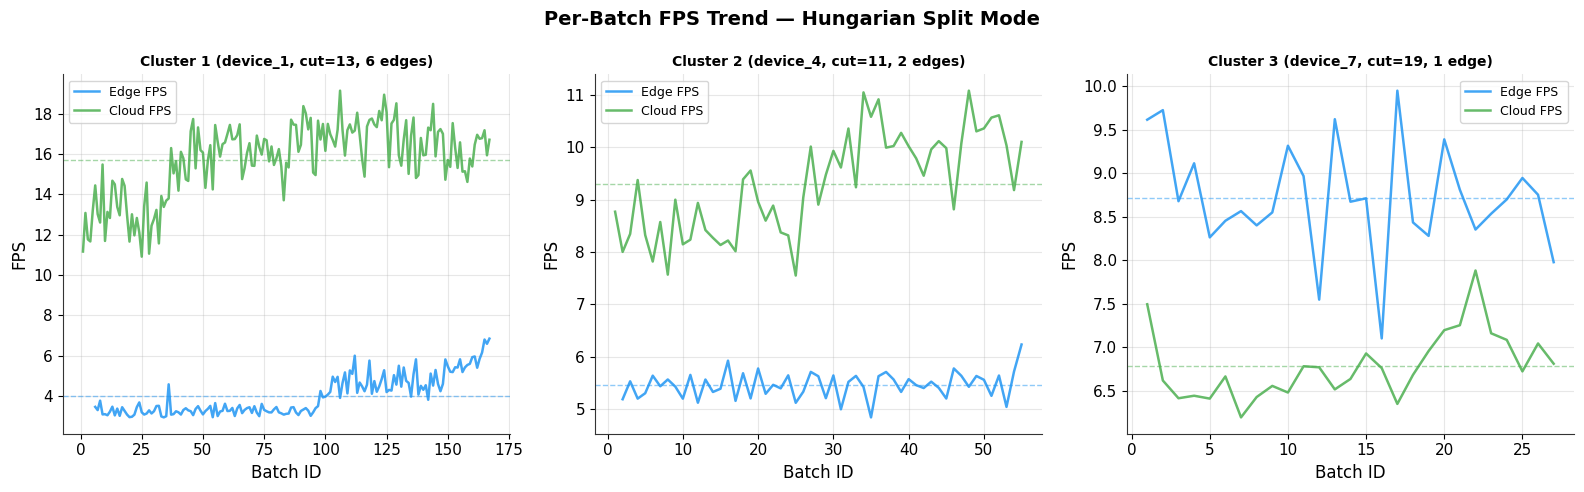

In [69]:
csv_hung = {
    'Cluster 1 (device_1, cut=13, 6 edges)': 'results/device_1_hungarian.csv',
    'Cluster 2 (device_4, cut=11, 2 edges)': 'results/device_4_hungarian.csv',
    'Cluster 3 (device_7, cut=19, 1 edge)':  'results/device_7_hungarian.csv',
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Per-Batch FPS Trend — Hungarian Split Mode', fontweight='bold', fontsize=14)

for ax, (title, fname) in zip(axes, csv_hung.items()):
    if os.path.exists(fname):
        df = pd.read_csv(fname)
        e = df[df['edge_fps'].notna() & (df['edge_fps'] > 0)]
        c = df[df['cloud_fps'].notna() & (df['cloud_fps'] > 0)]
        c = c.sort_values('cloud_arrival_order')
        ax.plot(e['batch_id'], e['edge_fps'],  color='#2196F3', lw=1.8, label='Edge FPS',  alpha=0.85)
        ax.plot(c['cloud_arrival_order'], c['cloud_fps'], color='#4CAF50', lw=1.8, label='Cloud FPS', alpha=0.85)
        ax.axhline(e['edge_fps'].mean(),  color='#2196F3', ls='--', lw=1, alpha=0.5)
        ax.axhline(c['cloud_fps'].mean(), color='#4CAF50', ls='--', lw=1, alpha=0.5)
    else:
        ax.text(0.5, 0.5, f'{fname}\nnot found', ha='center', va='center', transform=ax.transAxes, color='red')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Batch ID')
    ax.set_ylabel('FPS')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('charts/chart5_hungarian_fps_trend.png', dpi=200, bbox_inches='tight')
plt.show()

## Biểu đồ 6 — Per-Machine FPS Trend (Only Edge)
**Ý nghĩa:** FPS của từng máy edge khi chạy toàn bộ model (không split).

Mỗi đường = 1 máy. Cho thấy sự khác biệt phần cứng rõ rệt: device_2 nhanh gấp 4x machine_3–6.

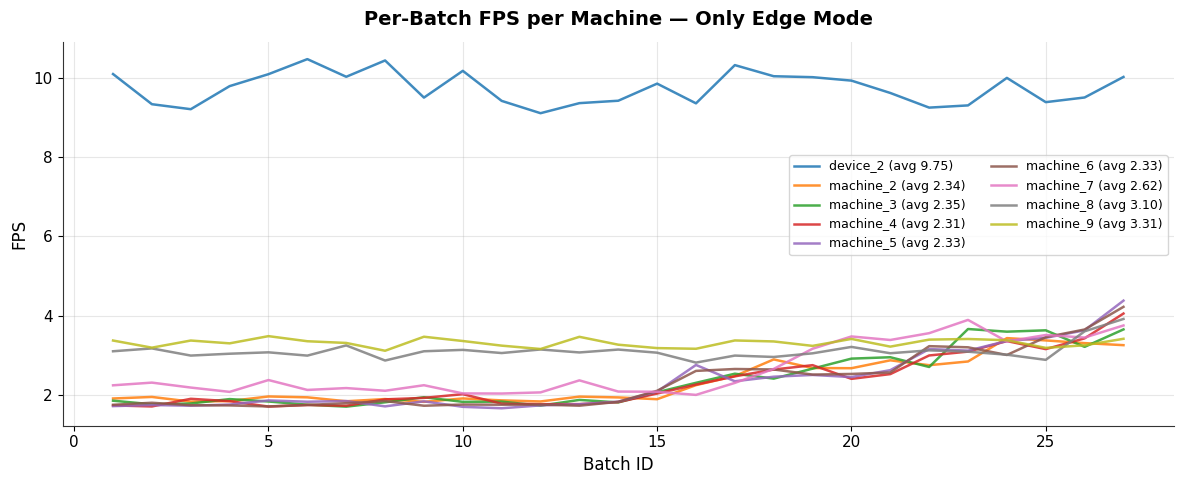

In [70]:
csv_edge = {
    'device_2':  'results/device_2_edge.csv',
    'machine_2': 'results/machine_2_only_edge.csv',
    'machine_3': 'results/machine_3_only_edge.csv',
    'machine_4': 'results/machine_4_only_edge.csv',
    'machine_5': 'results/machine_5_only_edge.csv',
    'machine_6': 'results/machine_6_only_edge.csv',
    'machine_7': 'results/machine_7_only_edge.csv',
    'machine_8': 'results/machine_8_only_edge.csv',
    'machine_9': 'results/machine_9_only_edge.csv',
}

fig, ax = plt.subplots(figsize=(12, 5))
cmap = plt.cm.tab10
for i, (name, fname) in enumerate(csv_edge.items()):
    if os.path.exists(fname):
        df = pd.read_csv(fname)
        df = df[df['edge_fps'].notna() & (df['edge_fps'] > 0)]
        avg = df['edge_fps'].mean()
        ax.plot(df['batch_id'], df['edge_fps'],
                label=f'{name} (avg {avg:.2f})', color=cmap(i/9), lw=1.8, alpha=0.85)
    else:
        print(f'Not found: {fname}')

ax.set_title('Per-Batch FPS per Machine — Only Edge Mode', fontweight='bold', pad=12)
ax.set_xlabel('Batch ID')
ax.set_ylabel('FPS')
ax.legend(loc='upper right', ncol=2, fontsize=9, bbox_to_anchor=(1, 0.72))
plt.tight_layout()
plt.savefig('charts/chart6_edge_fps_trend.png', dpi=200, bbox_inches='tight')
plt.show()

## Biểu đồ 7 — Cloud FPS Trend (Only Cloud)
**Ý nghĩa:** FPS của từng cloud device khi chạy Only Cloud.

Cloud nhận raw frame 150MB/batch từ 9 edge → FPS thấp và không ổn định do backpressure.

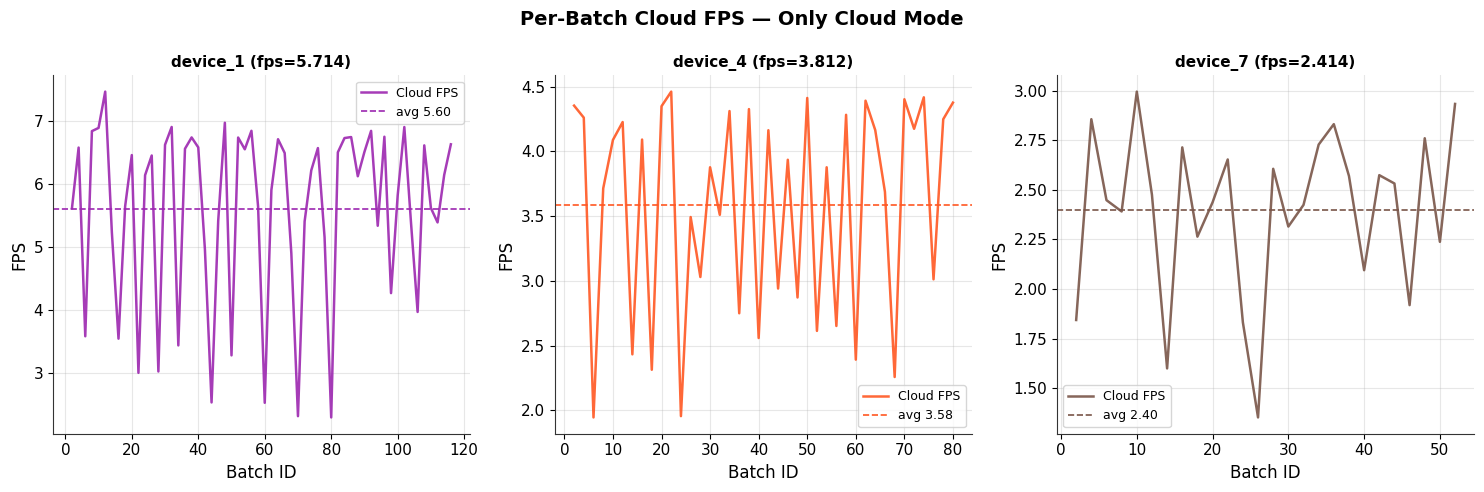

In [71]:
csv_cloud = {
    'device_1 (fps=5.714)': 'results/device_1_only_cloud.csv',
    'device_4 (fps=3.812)': 'results/device_4_only_cloud.csv',
    'device_7 (fps=2.414)': 'results/device_7_only_cloud.csv',
}
cloud_colors = ['#9C27B0', '#FF5722', '#795548']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Per-Batch Cloud FPS — Only Cloud Mode', fontweight='bold', fontsize=14)

for ax, (name, fname), col in zip(axes, csv_cloud.items(), cloud_colors):
    if os.path.exists(fname):
        df = pd.read_csv(fname)
        df_c = df[df['cloud_fps'].notna() & (df['cloud_fps'] > 0)]
        df_c = df_c[df_c['cloud_arrival_order'] % 2 == 0]
        df_c = df_c.sort_values('cloud_arrival_order')
        ax.plot(df_c['cloud_arrival_order'], df_c['cloud_fps'],
                color=col, lw=1.8, label='Cloud FPS', alpha=0.9)
        ax.axhline(df_c['cloud_fps'].mean(), color=col, ls='--', lw=1.2,
                   label=f"avg {df_c['cloud_fps'].mean():.2f}")
    else:
        ax.text(0.5, 0.5, f'{fname}\nnot found', ha='center', va='center',
                transform=ax.transAxes, color='red')
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Batch ID')
    ax.set_ylabel('FPS')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('charts/chart7_cloud_fps_trend.png', dpi=200, bbox_inches='tight')
plt.show()

## Tổng kết
Tất cả charts đã lưu vào thư mục `charts/`

In [72]:
print('=== SUMMARY ===')
print(f'Only Edge  total FPS: 30.443')
print(f'Hungarian  total FPS: 31.825')
print(f'Only Cloud total FPS: 11.940')
print()
print(f'Charts saved: {os.listdir("charts")}')

=== SUMMARY ===
Only Edge  total FPS: 30.443
Hungarian  total FPS: 31.825
Only Cloud total FPS: 11.940

Charts saved: ['chart10_utilization_only_edge.png', 'chart1_total_fps.png', 'chart2_ram_stacked.png', 'chart3b_latency_no_e2e.png', 'chart3b_latency_stacked.png', 'chart3_latency.png', 'chart4_msg_size.png', 'chart5_hungarian_fps_trend.png', 'chart6_edge_fps_trend.png', 'chart7_cloud_fps_trend.png', 'chart8_utilization_hungarian.png', 'chart9_utilization_only_cloud.png', 'chartA_fps_breakdown.png', 'chartB_fps_vs_e2e.png', 'chartC_fps_per_device.png']


## Biểu đồ 8 — Utilization Timeline: Hungarian

Edge (xanh dương) = inference partial layers. Cloud (xanh lá) = inference remaining layers.

Found 12 files
Device           Role    Batches   Busy(s)  Total(s)  Util%  Avg(s)
-----------------------------------------------------------------
device_2         Edge         28     100.9    104.81   96.3     3.6
machine_2        Edge         28    228.95    243.24   94.1    8.18
machine_3        Edge         28    227.98    241.93   94.2    8.14
machine_4        Edge         28    232.17    246.08   94.3    8.29
machine_5        Edge         28     227.8    242.26   94.0    8.14
machine_6        Edge         28    227.41    241.16   94.3    8.12
machine_7        Edge         28    205.58    221.21   92.9    7.34
machine_8        Edge         28     153.0    168.03   91.1    5.46
machine_9        Edge         28    152.07    164.83   92.3    5.43
device_1         Cloud       131    249.48     288.7   86.4     1.9
device_4         Cloud        56    178.26    246.45   72.3    3.18
device_7         Cloud        28    126.72    246.59   51.4    4.53


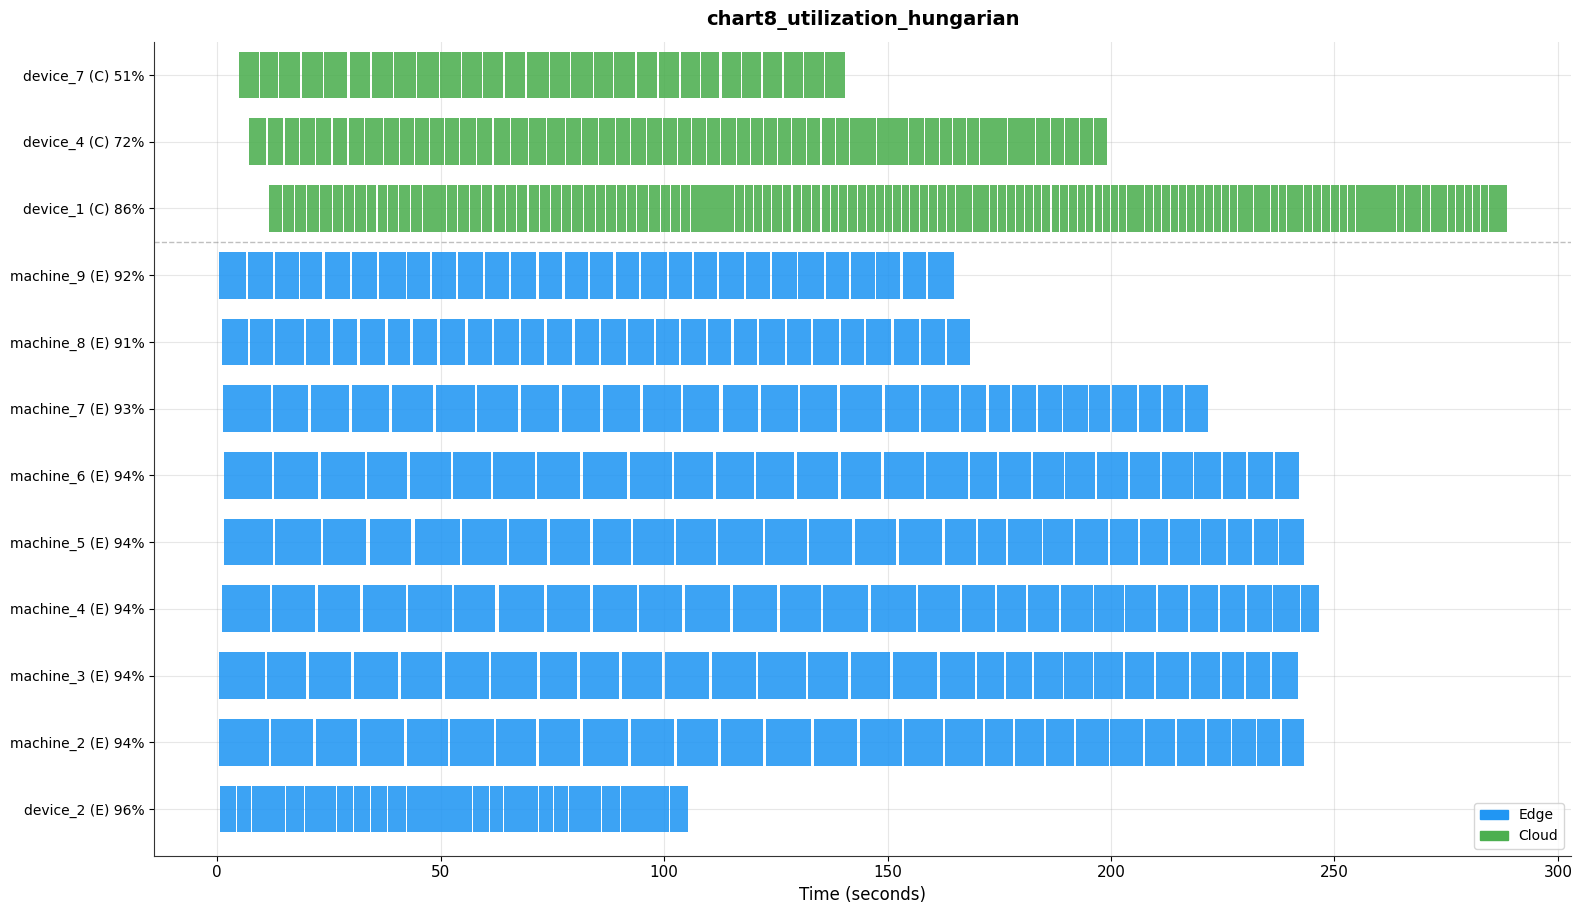

Saved charts/chart8_utilization_hungarian.png


In [73]:
import glob, os
import matplotlib.patches as mpatches

def parse_log(fpath):
    events = []
    with open(fpath) as f:
        for line in f:
            parts = line.strip().split(maxsplit=1)
            if len(parts) == 2:
                events.append((int(parts[0]), parts[1]))
    segs, start = [], None
    for ts, msg in events:
        if msg == 'get input':  start = ts
        elif msg == 'output' and start:
            segs.append((start, ts)); start = None
    return segs, events[0][0], events[-1][0]

files = sorted(glob.glob('timing/*_timing_hungarian.log'))
files = [f for f in files if True]
if not files:
    print('No files found: *_timing_hungarian.log')
else:
    print('Found', len(files), 'files')
    devices = []
    for fpath in files:
        fname = os.path.basename(fpath)
        label = fname.replace('_edge_timing_hungarian.log','').replace('_cloud_timing_hungarian.log','')
        role  = 'Edge' if '_edge_' in fname else 'Cloud'
        segs, t0, t1 = parse_log(fpath)
        busy  = sum(e - s for s, e in segs) / 1e9
        total = (t1 - t0) / 1e9
        util  = busy / total * 100 if total > 0 else 0
        avg   = busy / len(segs) if segs else 0
        devices.append({'label': label, 'role': role, 'segs': segs,
                        't0': t0, 't1': t1, 'busy': busy,
                        'total': total, 'util': util, 'avg': avg})

    devices.sort(key=lambda d: (0 if d['role']=='Edge' else 1, d['label']))
    global_start = min(d['t0'] for d in devices)

    print('Device'.ljust(16), 'Role'.ljust(6), 'Batches'.rjust(8),
          'Busy(s)'.rjust(9), 'Total(s)'.rjust(9), 'Util%'.rjust(6), 'Avg(s)'.rjust(7))
    print('-' * 65)
    for d in devices:
        print(d['label'][:15].ljust(16), d['role'][:5].ljust(6),
              str(len(d['segs'])).rjust(8),
              str(round(d['busy'],2)).rjust(9),
              str(round(d['total'],2)).rjust(9),
              str(round(d['util'],1)).rjust(6),
              str(round(d['avg'],2)).rjust(7))

    n = len(devices)
    fig, ax = plt.subplots(figsize=(16, max(5, n * 0.65 + 1.5)))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    ax.set_axisbelow(True)
    C_EDGE='#2196F3'; C_CLOUD='#4CAF50'
    def get_color(d): return C_EDGE if d['role']=='Edge' else C_CLOUD
    n_edge = sum(1 for d in devices if d['role']=='Edge')
    ax.axhline(n_edge, color='gray', ls='--', lw=1, alpha=0.5)
    for i, d in enumerate(devices):
        bars = [((s - global_start)/1e9, (e-s)/1e9) for s, e in d['segs']]
        ax.broken_barh(bars, (i+0.15, 0.7), facecolors=get_color(d),
                       edgecolors='none', alpha=0.88)
    ax.set_yticks([i+0.5 for i in range(n)])
    ax.set_yticklabels(
        [d['label'] + ' (' + d['role'][0] + ') ' + str(round(d['util'])) + '%'
         for d in devices], fontsize=10)
    ax.set_xlabel('Time (seconds)', fontsize=12)
    ax.set_title('chart8_utilization_hungarian', fontweight='bold', pad=12)
    ax.set_ylim(-0.2, n)
    ax.grid(axis='x', alpha=0.3)
    legend_handles = [
        mpatches.Patch(color='#2196F3', label='Edge'),
        mpatches.Patch(color='#4CAF50', label='Cloud'),
    ]
    ax.legend(handles=legend_handles, loc='lower right', fontsize=10)
    plt.tight_layout()
    plt.savefig('charts/chart8_utilization_hungarian.png', dpi=200, bbox_inches='tight')
    plt.show()
    print('Saved charts/chart8_utilization_hungarian.png')

## Biểu đồ 9 — Utilization Timeline: Only Cloud

Edge (xanh dương) = gửi raw frame 150MB. Cloud (xanh lá) = full model inference. Khoảng trắng lớn ở edge = backpressure.

Found 12 files
Device           Role    Batches   Busy(s)  Total(s)  Util%  Avg(s)
-----------------------------------------------------------------
device_2         Edge         28    715.11    718.67   99.5   25.54
machine_2        Edge         28    692.37    700.25   98.9   24.73
machine_3        Edge         28    705.13    713.12   98.9   25.18
machine_4        Edge         28    691.71    699.86   98.8    24.7
machine_5        Edge         28    619.32    626.91   98.8   22.12
machine_6        Edge         28    618.15    625.34   98.9   22.08
machine_7        Edge         28    692.19    699.34   99.0   24.72
machine_8        Edge         28    673.42    679.95   99.0   24.05
machine_9        Edge         28    618.27    624.49   99.0   22.08
device_1         Cloud       117    365.17    725.01   50.4    3.12
device_4         Cloud        83    470.88    725.59   64.9    5.67
device_7         Cloud        52    537.75    728.61   73.8   10.34


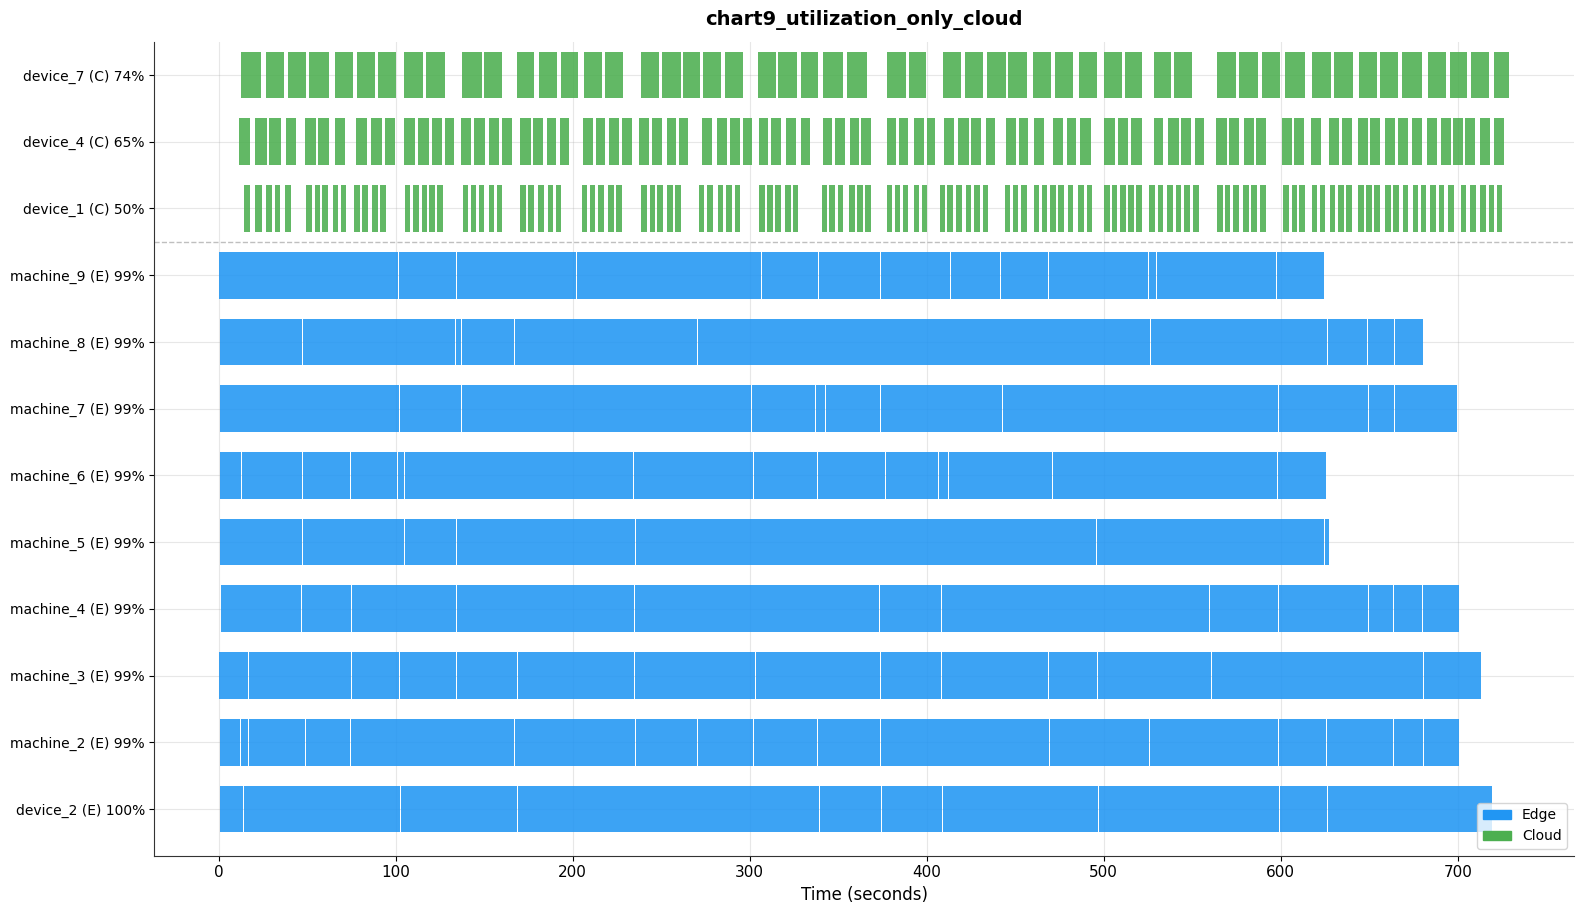

Saved charts/chart9_utilization_only_cloud.png


In [74]:
import glob, os
import matplotlib.patches as mpatches

def parse_log(fpath):
    events = []
    with open(fpath) as f:
        for line in f:
            parts = line.strip().split(maxsplit=1)
            if len(parts) == 2:
                events.append((int(parts[0]), parts[1]))
    segs, start = [], None
    for ts, msg in events:
        if msg == 'get input':  start = ts
        elif msg == 'output' and start:
            segs.append((start, ts)); start = None
    return segs, events[0][0], events[-1][0]

files = sorted(glob.glob('timing/*_timing.log'))
files = [f for f in files if '_hungarian' not in f and '_only_edge_' not in f]
if not files:
    print('No files found: *_timing.log')
else:
    print('Found', len(files), 'files')
    devices = []
    for fpath in files:
        fname = os.path.basename(fpath)
        label = fname.replace('_edge_timing.log','').replace('_cloud_timing.log','')
        role  = 'Edge' if '_edge_' in fname else 'Cloud'
        segs, t0, t1 = parse_log(fpath)
        busy  = sum(e - s for s, e in segs) / 1e9
        total = (t1 - t0) / 1e9
        util  = busy / total * 100 if total > 0 else 0
        avg   = busy / len(segs) if segs else 0
        devices.append({'label': label, 'role': role, 'segs': segs,
                        't0': t0, 't1': t1, 'busy': busy,
                        'total': total, 'util': util, 'avg': avg})

    devices.sort(key=lambda d: (0 if d['role']=='Edge' else 1, d['label']))
    global_start = min(d['t0'] for d in devices)

    print('Device'.ljust(16), 'Role'.ljust(6), 'Batches'.rjust(8),
          'Busy(s)'.rjust(9), 'Total(s)'.rjust(9), 'Util%'.rjust(6), 'Avg(s)'.rjust(7))
    print('-' * 65)
    for d in devices:
        print(d['label'][:15].ljust(16), d['role'][:5].ljust(6),
              str(len(d['segs'])).rjust(8),
              str(round(d['busy'],2)).rjust(9),
              str(round(d['total'],2)).rjust(9),
              str(round(d['util'],1)).rjust(6),
              str(round(d['avg'],2)).rjust(7))

    n = len(devices)
    fig, ax = plt.subplots(figsize=(16, max(5, n * 0.65 + 1.5)))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    ax.set_axisbelow(True)
    C_EDGE='#2196F3'; C_CLOUD='#4CAF50'
    def get_color(d): return C_EDGE if d['role']=='Edge' else C_CLOUD
    n_edge = sum(1 for d in devices if d['role']=='Edge')
    ax.axhline(n_edge, color='gray', ls='--', lw=1, alpha=0.5)
    for i, d in enumerate(devices):
        bars = [((s - global_start)/1e9, (e-s)/1e9) for s, e in d['segs']]
        ax.broken_barh(bars, (i+0.15, 0.7), facecolors=get_color(d),
                       edgecolors='none', alpha=0.88)
    ax.set_yticks([i+0.5 for i in range(n)])
    ax.set_yticklabels(
        [d['label'] + ' (' + d['role'][0] + ') ' + str(round(d['util'])) + '%'
         for d in devices], fontsize=10)
    ax.set_xlabel('Time (seconds)', fontsize=12)
    ax.set_title('chart9_utilization_only_cloud', fontweight='bold', pad=12)
    ax.set_ylim(-0.2, n)
    ax.grid(axis='x', alpha=0.3)
    legend_handles = [
        mpatches.Patch(color='#2196F3', label='Edge'),
        mpatches.Patch(color='#4CAF50', label='Cloud'),
    ]
    ax.legend(handles=legend_handles, loc='lower right', fontsize=10)
    plt.tight_layout()
    plt.savefig('charts/chart9_utilization_only_cloud.png', dpi=200, bbox_inches='tight')
    plt.show()
    print('Saved charts/chart9_utilization_only_cloud.png')

## Biểu đồ 10 — Utilization Timeline: Only Edge

Mỗi máy chạy full model độc lập. Màu đậm hơn = util% cao hơn. device_2 nhanh nhất (~3.3s/batch).

Found 9 files


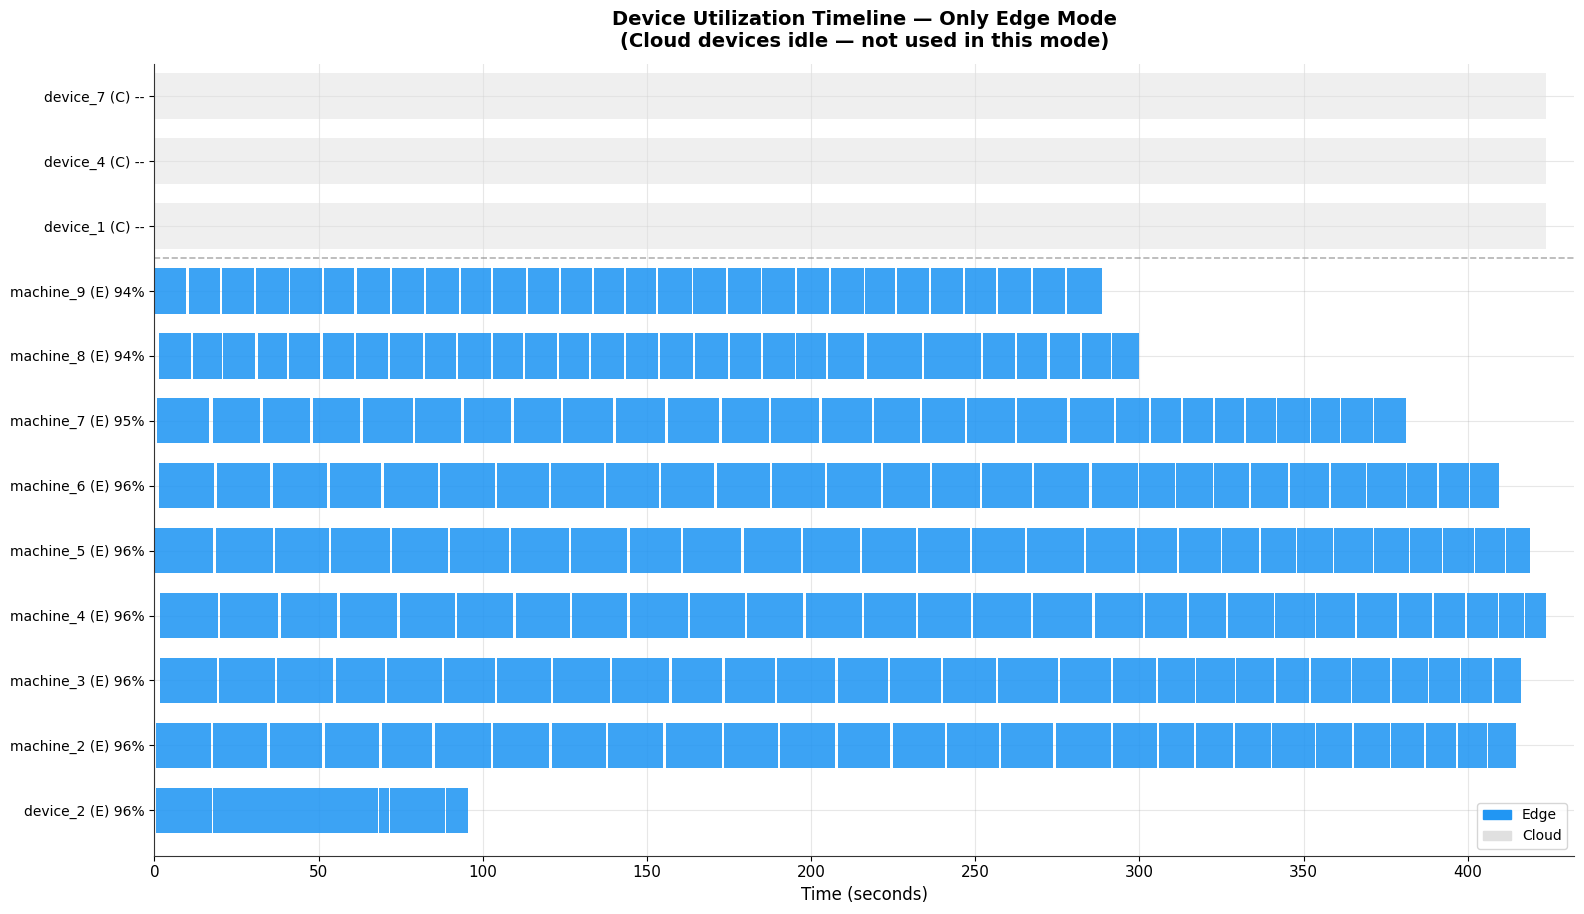

Saved charts/chart10_utilization_only_edge.png


In [75]:
import glob, os
import matplotlib.patches as mpatches

def parse_log(fpath):
    events = []
    with open(fpath) as f:
        for line in f:
            parts = line.strip().split(maxsplit=1)
            if len(parts) == 2:
                events.append((int(parts[0]), parts[1]))
    segs, start = [], None
    for ts, msg in events:
        if msg == 'get input':  start = ts
        elif msg == 'output' and start:
            segs.append((start, ts)); start = None
    return segs, events[0][0], events[-1][0]

files = sorted(glob.glob('timing/*_only_edge_timing.log'))
if not files:
    print('No files found: *_only_edge_timing.log')
else:
    print('Found', len(files), 'files')
    devices = []
    for fpath in files:
        fname = os.path.basename(fpath)
        label = fname.replace('_only_edge_timing.log','')
        segs, t0, t1 = parse_log(fpath)
        busy  = sum(e - s for s, e in segs) / 1e9
        total = (t1 - t0) / 1e9
        util  = busy / total * 100 if total > 0 else 0
        devices.append({'label': label, 'role': 'Edge', 'segs': segs,
                        't0': t0, 't1': t1, 'busy': busy, 'total': total, 'util': util})

    # Sort edge: cùng thứ tự như Hungarian (alphabetical)
    devices.sort(key=lambda d: d['label'])

    # Thêm 3 cloud rows rỗng (không dùng trong only_edge)
    cloud_labels = ['device_1', 'device_4', 'device_7']
    for cl in cloud_labels:
        devices.append({'label': cl, 'role': 'Cloud', 'segs': [],
                        't0': 0, 't1': 0, 'busy': 0, 'total': 0, 'util': 0})

    global_start = min(d['t0'] for d in devices if d['t0'] > 0)
    global_end   = max(d['t1'] for d in devices if d['t1'] > 0)
    total_span   = (global_end - global_start) / 1e9

    n = len(devices)
    fig, ax = plt.subplots(figsize=(16, max(5, n * 0.65 + 1.5)))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    ax.set_axisbelow(True)

    C_EDGE  = '#2196F3'
    C_CLOUD_EMPTY = '#E0E0E0'

    for i, d in enumerate(devices):
        if d['role'] == 'Edge':
            bars = [((s - global_start)/1e9, (e-s)/1e9) for s, e in d['segs']]
            ax.broken_barh(bars, (i+0.15, 0.7), facecolors=C_EDGE, edgecolors='none', alpha=0.88)
        else:
            # Cloud không dùng: vẽ 1 bar xám nhạt toàn chiều dài + chữ "not used"
            ax.broken_barh([(0, total_span)], (i+0.15, 0.7),
                           facecolors=C_CLOUD_EMPTY, edgecolors='none', alpha=0.5)

    # Đường phân cách edge / cloud
    n_edge = sum(1 for d in devices if d['role'] == 'Edge')
    ax.axhline(n_edge, color='gray', ls='--', lw=1.2, alpha=0.6)


    ax.set_yticks([i+0.5 for i in range(n)])
    ax.set_yticklabels(
        [d['label'] + ' (E) ' + str(round(d['util'])) + '%' if d['role']=='Edge'
         else d['label'] + ' (C) --'
         for d in devices], fontsize=10)

    ax.set_xlabel('Time (seconds)', fontsize=12)
    ax.set_title('Device Utilization Timeline — Only Edge Mode\n'
                 '(Cloud devices idle — not used in this mode)',
                 fontweight='bold', pad=12)
    ax.set_xlim(0, total_span * 1.02)
    ax.set_ylim(-0.2, n)
    ax.grid(axis='x', alpha=0.3)

    legend_handles = [
        mpatches.Patch(color=C_EDGE,        label='Edge'),
        mpatches.Patch(color=C_CLOUD_EMPTY, label='Cloud'),
    ]
    ax.legend(handles=legend_handles, loc='lower right', fontsize=10)

    plt.tight_layout()
    plt.savefig('charts/chart10_utilization_only_edge.png', dpi=200, bbox_inches='tight')
    plt.show()
    print('Saved charts/chart10_utilization_only_edge.png')